In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


#1. Identify which age groups and gender contribute most to sales.

Gender Sales Summary:
   Gender       Amount
0      F  74335856.43
1      M  31913276.00

Age Group Sales Summary:
   Age Group       Amount
2     26-35  42613443.94
3     36-45  22144995.49
1     18-25  17240732.00
4     46-50   9207844.00
5     51-55   8261477.00
6       55+   4080987.00
0      0-17   2699653.00

Age-Gender Combined Sales Summary (Top 5):
   Age Group Gender       Amount
4     26-35      F  30963954.94
6     36-45      F  15509957.49
2     18-25      F  11887003.00
5     26-35      M  11649489.00
8     46-50      F   6743393.00


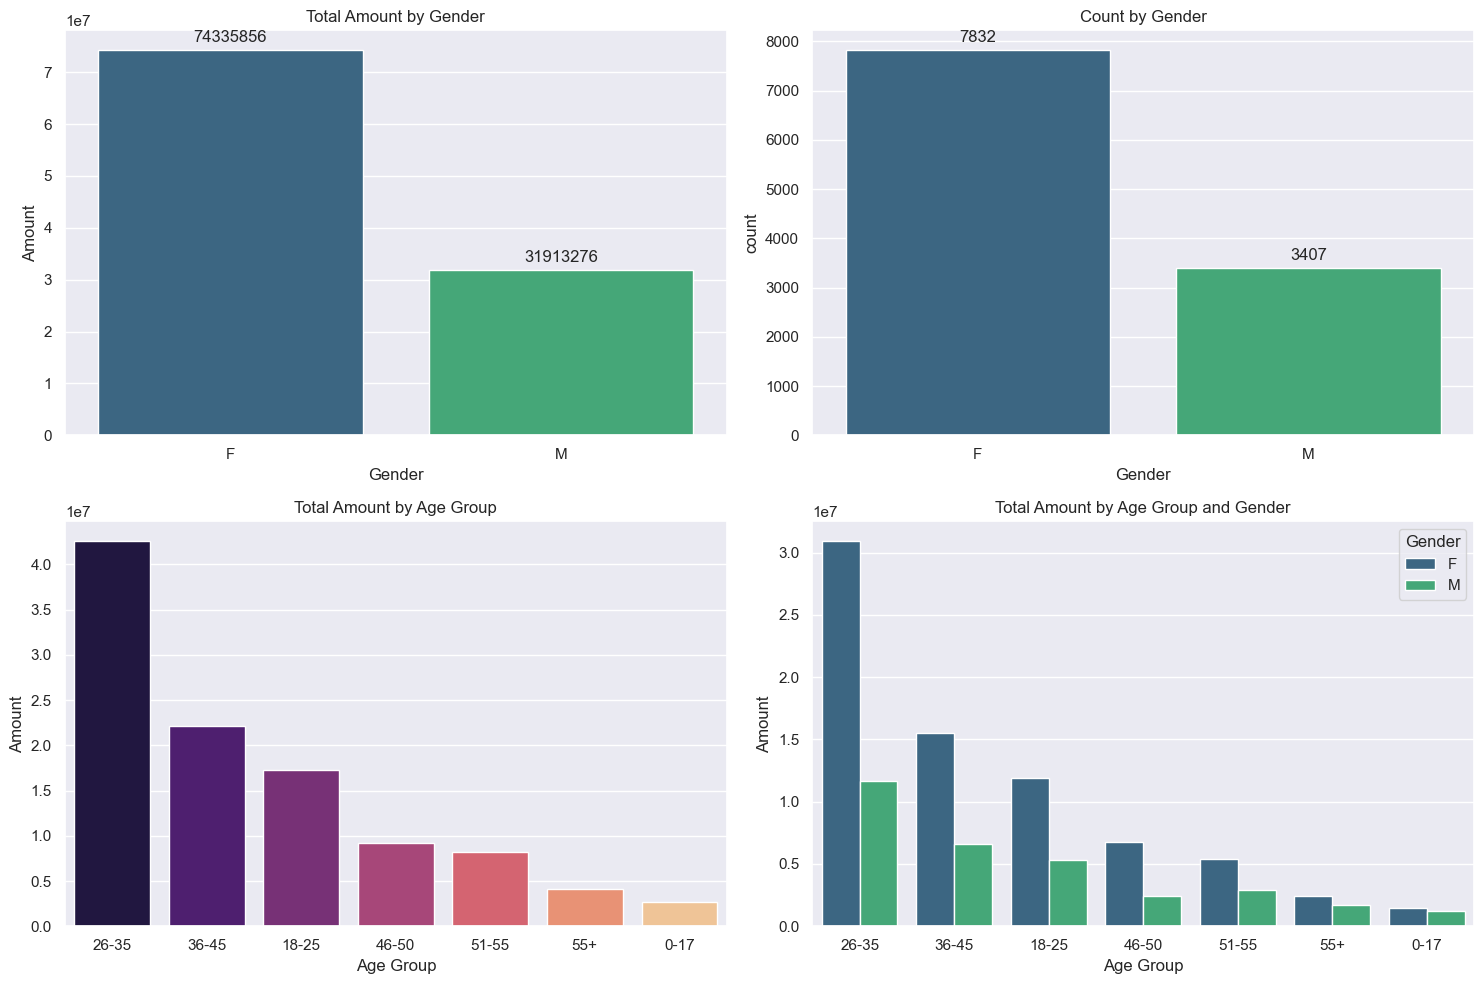

In [4]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)

gender_sales = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
gender_counts = df['Gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

age_sales = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
age_counts = df.groupby(['Age Group'], as_index=False)['Orders'].count().sort_values(by='Orders', ascending=False)

age_gender_sales = df.groupby(['Age Group', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(15, 10)})

plt.subplot(2, 2, 1)
ax1 = sns.barplot(x='Gender', y='Amount', data=gender_sales, hue='Gender', palette='viridis', legend=False)
plt.title('Total Amount by Gender')
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

    plt.subplot(2, 2, 2)
ax2 = sns.countplot(data=df, x='Gender', hue='Gender', palette='viridis', legend=False)
plt.title('Count by Gender')
for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

    plt.subplot(2, 2, 3)
ax3 = sns.barplot(x='Age Group', y='Amount', data=age_sales, hue='Age Group', palette='magma', legend=False)
plt.title('Total Amount by Age Group')

plt.subplot(2, 2, 4)
ax4 = sns.barplot(x='Age Group', y='Amount', data=age_gender_sales, hue='Gender', palette='viridis')
plt.title('Total Amount by Age Group and Gender')

plt.tight_layout()
plt.savefig('q1_analysis.png')

print("Gender Sales Summary:\n", gender_sales)
print("\nAge Group Sales Summary:\n", age_sales)
print("\nAge-Gender Combined Sales Summary (Top 5):\n", age_gender_sales.head())

#2. Determine the most profitable states/zones for Diwali sales.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Top 5 States:
              State       Amount
14   Uttar Pradesh  19374968.00
10     Maharashtra  14427543.00
7        Karnataka  13523540.00
2            Delhi  11603819.45
9   Madhya Pradesh   8101142.00

Sales by Zone:
        Zone       Amount
0   Central  41600873.45
3  Southern  26606668.98
4   Western  18373625.00
2  Northern  12618752.00
1   Eastern   7049213.00


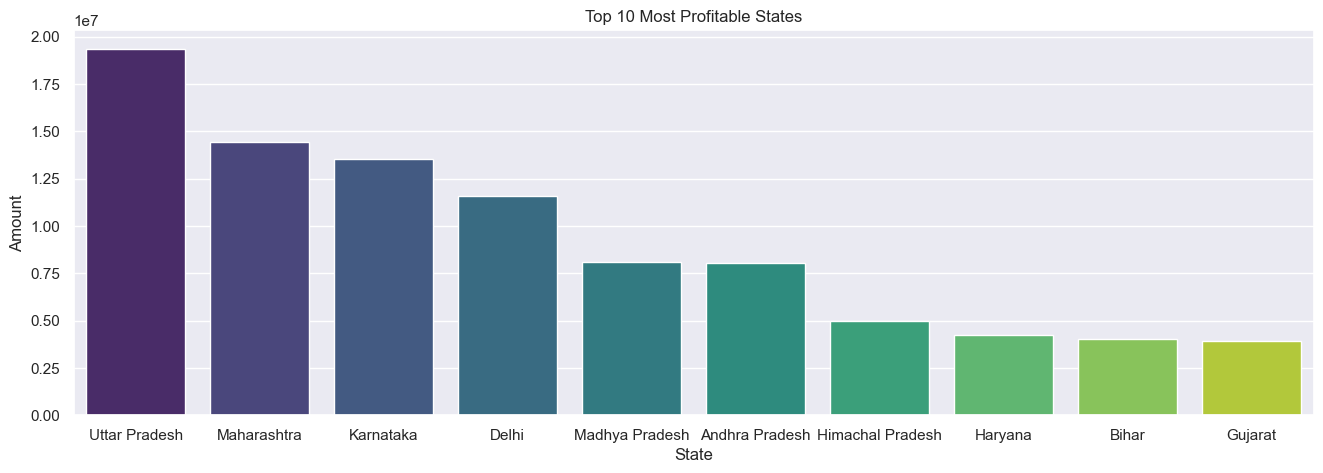

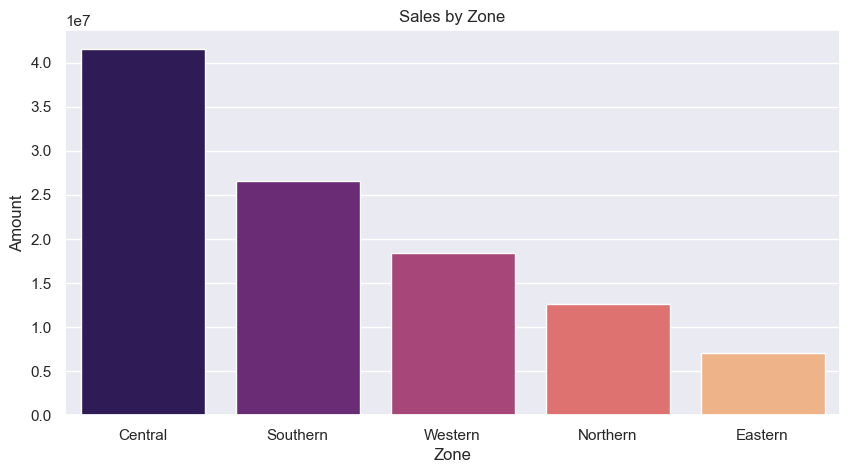

In [6]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)

state_sales = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(16, 5))
sns.barplot(data=state_sales, x='State', y='Amount', hue='State', palette='viridis', legend=False)
plt.title('Top 10 Most Profitable States')
plt.savefig('top_states.png')

zone_sales = df.groupby(['Zone'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=zone_sales, x='Zone', y='Amount', hue='Zone', palette='magma', legend=False)
plt.title('Sales by Zone')
plt.savefig('zone_sales.png')

print("Top 5 States:\n", state_sales.head())
print("\nSales by Zone:\n", zone_sales)

#3 Find top-performing occupations and their buying capacity.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Top 10 Occupations by Buying Capacity:
     Occupation       Amount
10    IT Sector  14755079.00
8    Healthcare  13034587.49
2      Aviation  12602298.00
3       Banking  10770610.95
7          Govt   8517212.00
9   Hospitality   6376405.00
12        Media   6295832.99
1    Automobile   5368596.00
4      Chemical   5297436.00
11       Lawyer   4981665.00


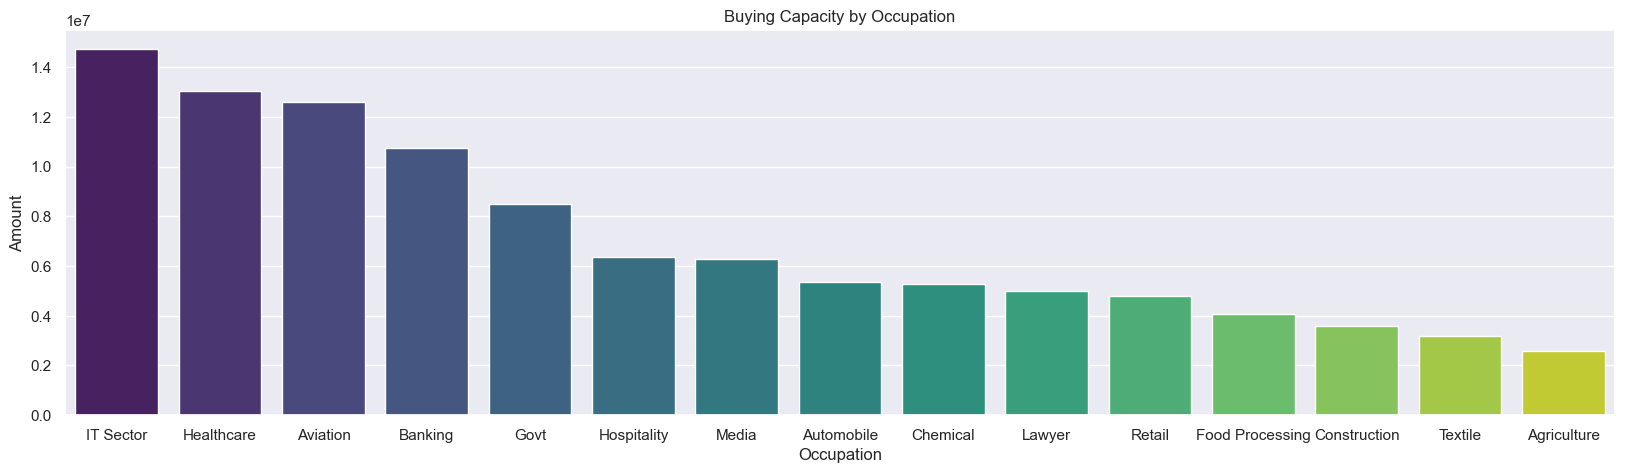

In [8]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)

occ_sales = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(20, 5))
# Removing legend=False to avoid AttributeError, while keeping hue to avoid FutureWarning
sns.barplot(data=occ_sales, x='Occupation', y='Amount', hue='Occupation', palette='viridis')
plt.title('Buying Capacity by Occupation')
plt.savefig('occupation_sales.png')

print("Top 10 Occupations by Buying Capacity:")
print(occ_sales.head(10))

#4. Highlight best-selling product categories.

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Top 5 Categories by Amount:
         Product_Category       Amount
6                   Food  33933883.50
3     Clothing & Apparel  16495019.00
5  Electronics & Gadgets  15643846.00
7       Footwear & Shoes  15575209.45
8              Furniture   5440051.99

Top 5 Categories by Orders:
          Product_Category  Orders
3      Clothing & Apparel    6634
6                    Food    6110
5   Electronics & Gadgets    5226
7        Footwear & Shoes    2646
11        Household items    1331


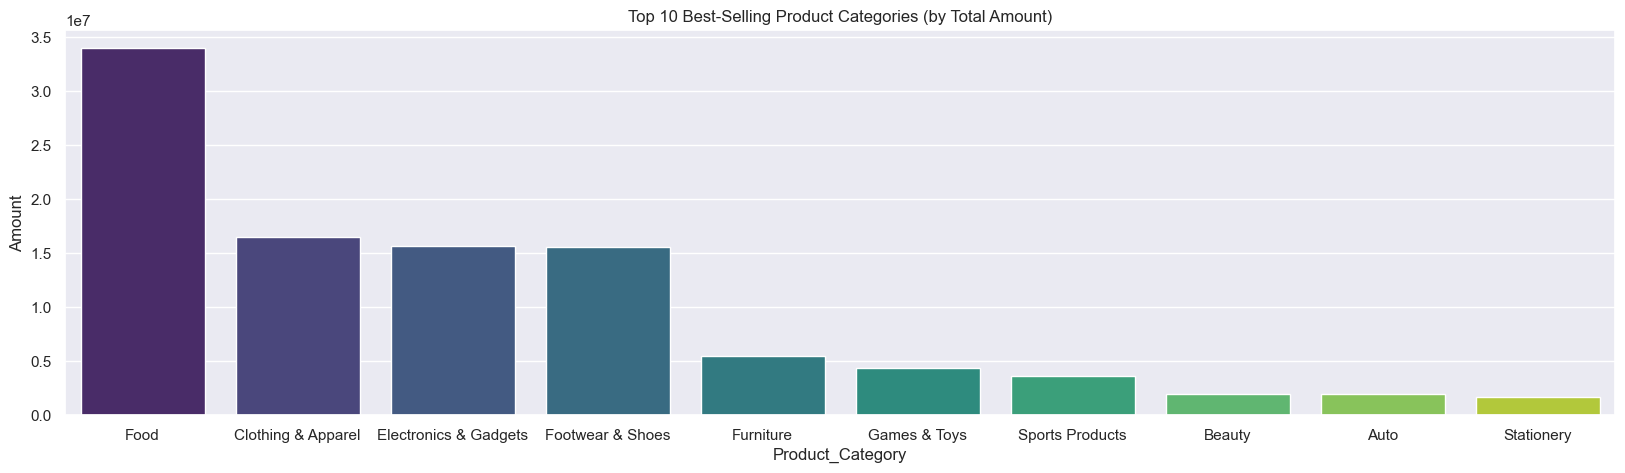

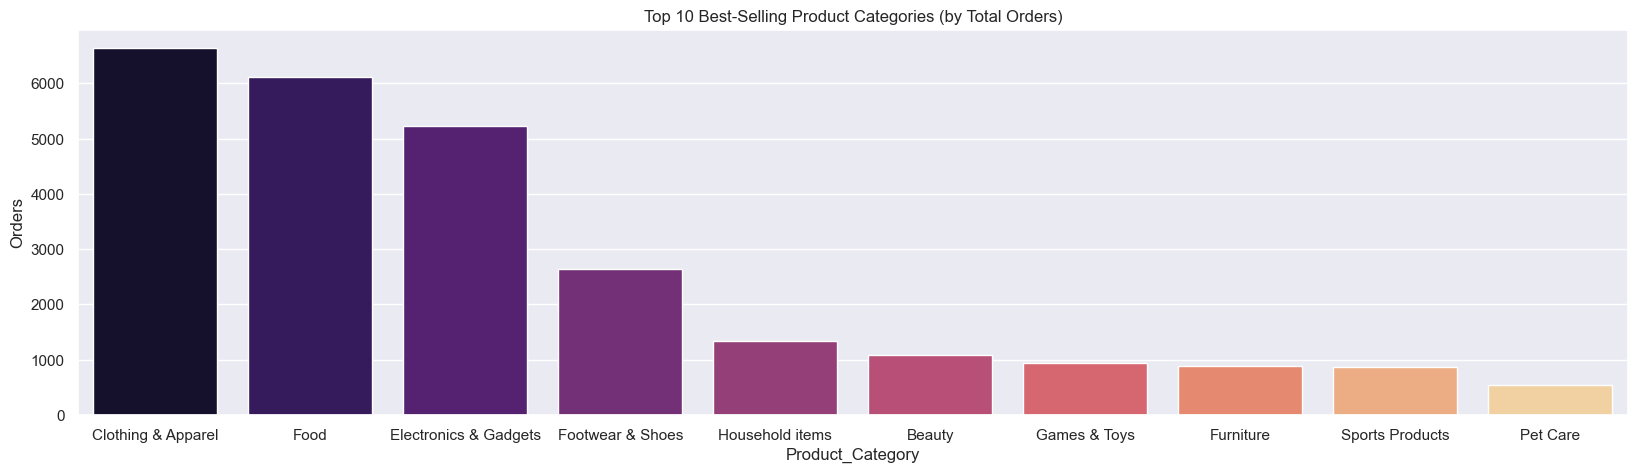

In [10]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

df.drop(['Status', 'unnamed1'], axis=1, inplace=True)
df.dropna(inplace=True)

prod_sales = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(20, 5))
sns.barplot(data=prod_sales, x='Product_Category', y='Amount', hue='Product_Category', palette='viridis')
plt.title('Top 10 Best-Selling Product Categories (by Total Amount)')
plt.savefig('product_category_amount.png')

prod_orders = df.groupby(['Product_Category'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

plt.figure(figsize=(20, 5))
sns.barplot(data=prod_orders, x='Product_Category', y='Orders', hue='Product_Category', palette='magma')
plt.title('Top 10 Best-Selling Product Categories (by Total Orders)')
plt.savefig('product_category_orders.png')

print("Top 5 Categories by Amount:\n", prod_sales.head())
print("\nTop 5 Categories by Orders:\n", prod_orders.head())

#5. Provide insights for targeted marketing campaigns.

The insights for the targeted marketing campaigns are as follows:

1. Key Findings
    * Top Customer Segment: Married females aged 26-35 years are the most significant contributors to sales revenue.
    * Geographic Leaders: The Central Zone is the top-performing region, with Uttar Pradesh being the state with the highest total sales value.
    * Professional Power: Customers working in the IT Sector, Healthcare, and Aviation sectors have the highest purchasing capacity.
    * Product Preferences: While Food items generate the most revenue, Clothing & Apparel is the category with the highest volume of orders.

2. Targeted Marketing Recommendations.
To maximize revenue for future festive seasons, the following strategies are recommended:

    * Audience Targeting: Focus digital marketing spend on Females (26-35). Use campaigns centered around "Family" and "Festive Essentials" to appeal to the married demographic within this age bracket.
    * Regional Expansion: Since UP, Maharashtra, and Karnataka show massive demand, consider launching exclusive "State-Specific" festive deals or pop-up events in major cities like Lucknow, Mumbai, and Bangalore.
    * Cross-Selling Strategy: Use Clothing as a "hook" category. Since order frequency is highest here, offer bundle deals where a clothing purchase unlocks discounts on high-value Electronics or Food hampers.
    * Corporate Partnerships: Design exclusive "Festive Benefit" programs for employees in the IT and Healthcare sectors. Direct outreach to major tech hubs and hospital networks can drive bulk sales.

3. Married women aged 26-35 years from UP, Maharashtra, and Karnataka working in the IT, Healthcare, and Aviation sectors are more likely to buy products from the Food, Clothing, and Electronics categories.

    Key Metrics Summary:
    
    * Top Gender: Female (Approx. 70% of total sales)
    * Top Age Group: 26-35
    * Top State: Uttar Pradesh
    * Top Category (Revenue): Food
    * Top Category (Orders): Clothing & Apparel